In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

Data Gabungan 2023-2024

In [2]:
Clust_data = pd.read_excel('D:/Kerjaan/Project P64180125 (k-Means, DBSCAN and TOPSIS in Python)/Post Revisi/Clustering Data Frame.xlsx',index_col=0)

In [3]:
# Delete rows that contains NaN
Clust_data = Clust_data.dropna()
Clust_data.head()

# Mengganti "-" dengan 0
Clust_data = Clust_data.replace('-', 0)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18016\3169386807.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Clust_data = Clust_data.replace('-', 0)


In [4]:
# Define the data
X = Clust_data.iloc[:,1:].values
X

array([[ 69.83,  68.28, 157.  , ...,   0.  ,   0.  ,   0.  ],
       [303.1 , 297.54, 290.  , ...,   1.  ,   0.  ,   0.  ],
       [167.67, 163.32, 201.  , ...,   0.  ,   0.  ,   0.  ],
       ...,
       [175.1 , 167.26, 150.  , ...,   0.  ,   0.  ,   0.  ],
       [186.62, 178.37, 135.  , ...,   0.  ,   0.  ,   0.  ],
       [100.48,  98.39, 135.  , ...,   0.  ,   0.  ,   0.  ]])

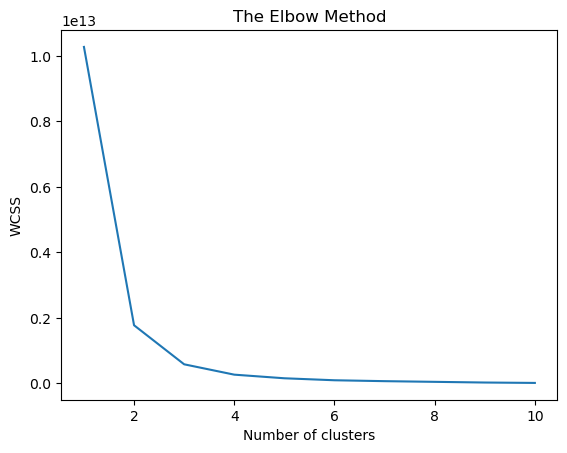

In [5]:
# Using the elbow method to find the optimal number of clusters
wcss =[]
for i in range (1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter =300, n_init = 10, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the graph to visualize the Elbow Method to find the optimal number of cluster
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

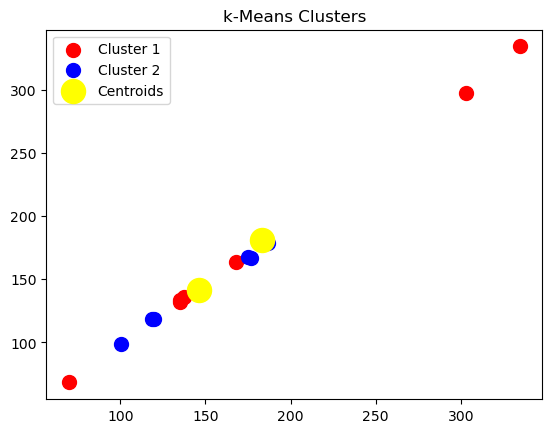

In [6]:
# K-Means Clustering
kmeans=KMeans(n_clusters= 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
Y_Kmeans = kmeans.fit_predict(X)

# Visualising the clusters
plt.scatter(X[Y_Kmeans == 0, 0], X[Y_Kmeans == 0,1],s = 100, c='red', label = 'Cluster 1')
plt.scatter(X[Y_Kmeans == 1, 0], X[Y_Kmeans == 1,1],s = 100, c='blue', label = 'Cluster 2')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('k-Means Clusters')
plt.legend()
plt.show()

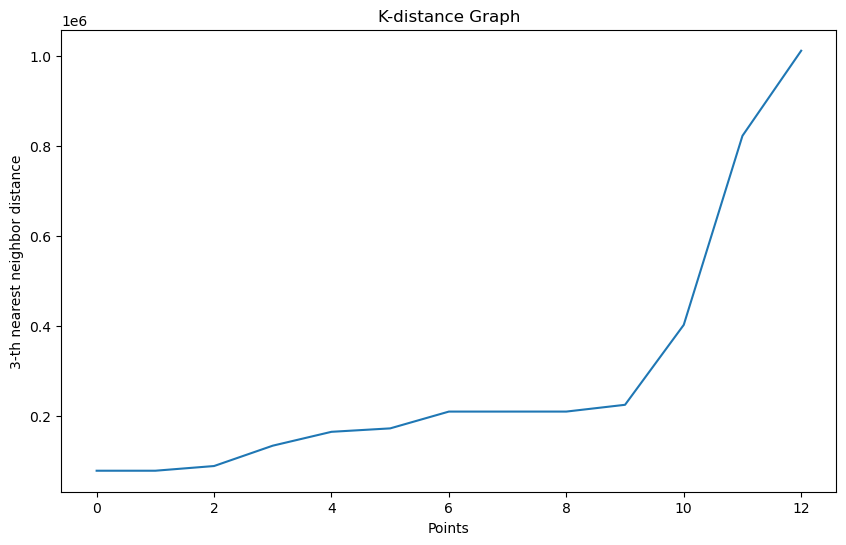

In [7]:
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=3)

In [8]:
X.shape

(13, 99)

In [9]:
# Perform DBSCAN clustering
# Find optimal min_samples using Silhouette analysis
best_min_samples = 2  # Initialize
best_silhouette_score = -1

for min_samples in range(2, 99): # Test a range of min_samples
  dbscan = DBSCAN(eps=0.2, min_samples=min_samples) # Use the epsilon determined previously
  clusters = dbscan.fit_predict(X)

  # Check if the clustering resulted in more than one cluster and no all points are noise
  if len(set(clusters)) > 1 and -1 not in clusters or list(clusters).count(-1) < len(clusters):
    silhouette_avg = silhouette_score(X, clusters)
    if silhouette_avg > best_silhouette_score:
      best_silhouette_score = silhouette_avg
      best_min_samples = min_samples

print(f"Optimal min_samples based on Silhouette Score: {best_min_samples}")

# Perform DBSCAN clustering with the optimal min_samples
dbscan = DBSCAN(eps=0.2, min_samples=best_min_samples)
clusters = dbscan.fit_predict(X)

Optimal min_samples based on Silhouette Score: 2


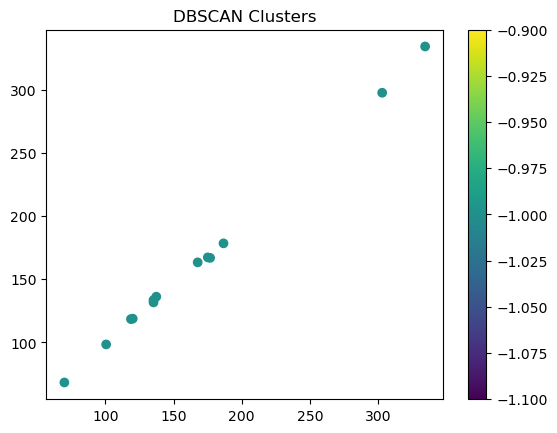

In [10]:
# Visualize the results
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clusters')
plt.show()

In [11]:
# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters+1}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 1
Number of noise points: 13


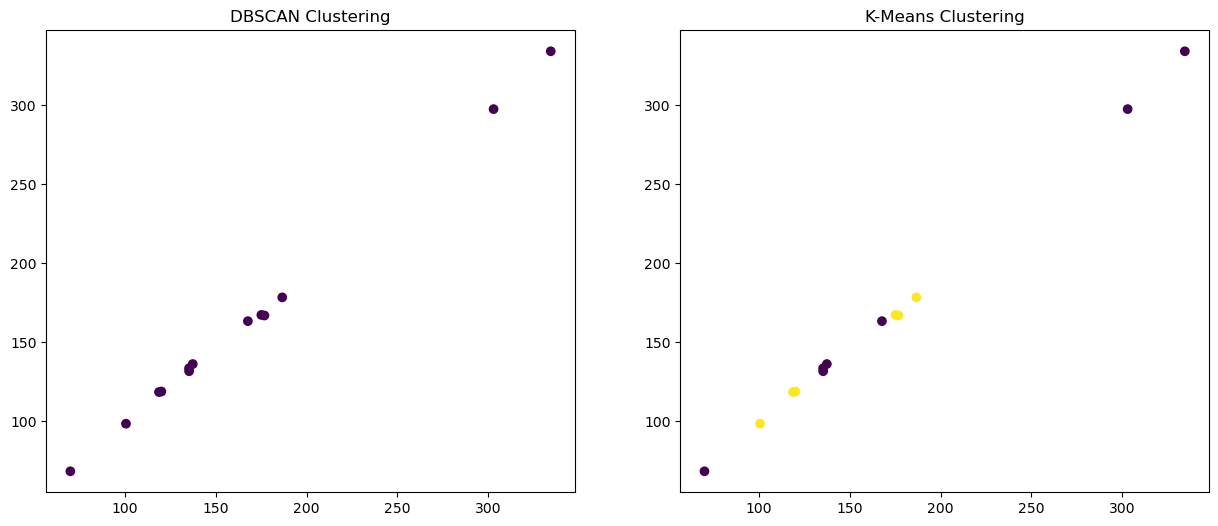

In [12]:
# DBSCAN clustering
dbscan = DBSCAN(eps=0.2, min_samples=2)
dbscan_labels = dbscan.fit_predict(X)

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans_labels = kmeans.fit_predict(X)

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
ax1.set_title('DBSCAN Clustering')
ax2.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
ax2.set_title('K-Means Clustering')
plt.show()

In [13]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for K-Means
silhouette_kmeans = silhouette_score(X, kmeans_labels)
print(f"Silhouette Score for K-Means: {silhouette_kmeans}")

# Calculate Silhouette Score for DBSCAN
silhouette_dbscan = best_silhouette_score
print(f"Silhouette Score for DBSCAN: {silhouette_dbscan}")

# Compare the scores
if silhouette_kmeans > silhouette_dbscan:
    print("K-Means is the better clustering method based on Silhouette Score.")
elif silhouette_dbscan > silhouette_kmeans:
    print("DBSCAN is the better clustering method based on Silhouette Score.")
else:
    print("Both K-Means and DBSCAN have similar Silhouette Scores.")

Silhouette Score for K-Means: 0.7367520043043646
Silhouette Score for DBSCAN: -1
K-Means is the better clustering method based on Silhouette Score.


TOPSIS

In [14]:
TOPSIS_data = pd.read_excel('D:/Kerjaan/Project P64180125 (k-Means, DBSCAN and TOPSIS in Python)/Post Revisi/TOPSIS Data Frame.xlsx',index_col=0)

In [15]:
# Delete rows that contains NaN
TOPSIS_data = TOPSIS_data.dropna()
TOPSIS_data.head()

# Mengganti "-" dengan 0
TOPSIS_data = TOPSIS_data.replace('-', 0)

In [16]:
# Calculate the mean of each feature for each cluster
criteria_matrix = TOPSIS_data.iloc[:,1:].values

cluster_means = []
for i in range(len(kmeans.cluster_centers_)):
    cluster_data = criteria_matrix[kmeans_labels == i]
    cluster_means.append(np.mean(cluster_data, axis=0))

criteria_weight = np.array(cluster_means)

# Criteria preference can be set based on domain knowledge or cluster characteristics
criteria_preference = np.ones(criteria_matrix.shape[1])

In [17]:
criteria_matrix = np.array(criteria_matrix, dtype=np.float64)
column_sums = (criteria_matrix ** 2).sum(axis=0)
with np.errstate(divide='ignore', invalid='ignore'): # Suppress warnings for division by zero
    norm_matrix = criteria_matrix / np.sqrt(column_sums)
    norm_matrix = np.nan_to_num(norm_matrix) #Handle NaN values resulting from division by zero

In [18]:
def weighted_matrix(criteria_weight, normalized_matrix):
    normalized_rows = len(normalized_matrix)
    normalized_columns = len(normalized_matrix[0])

    weighted_matrix = []
    for i in range(normalized_rows):
        weighted_matrix_rows = []
        for j in range(normalized_columns):
            weighted_matrix_rows.append(normalized_matrix [i][j]* criteria_weight[j])
        weighted_matrix.append(weighted_matrix_rows)

    print('\nWeighted matrix from normalized matrix: ')
    for i in weighted_matrix:
        for j in i:
            print(f'{j:.4f}',end=' ')
        print()
    return weighted_matrix

In [19]:
weighted_matrix_1 = weighted_matrix(criteria_weight[0].flatten(),norm_matrix)
weighted_matrix_2 = weighted_matrix(criteria_weight[1].flatten(),norm_matrix)


Weighted matrix from normalized matrix: 
34.5953 0.0000 0.0000 0.0000 10332.4462 3.1900 4.8071 4.4887 0.1750 0.1644 0.0000 4520.7360 3573.2999 
6.8506 1.2374 121.5357 172.7310 541865.1837 169.5510 2.9260 2.2443 0.0000 0.3288 0.0000 5302.9003 3661.2265 
7.7069 0.0000 0.0000 0.0000 45845.1930 12.4412 1.0450 2.8856 0.0000 0.1644 0.0000 4201.1537 2639.6623 
23.1206 0.0000 0.0000 0.0000 75505.8824 97.7749 0.8360 3.5268 0.0000 0.0000 0.0000 5432.0874 2875.4796 
28.2586 0.0000 0.0000 0.0000 56544.8251 5.2636 0.4180 2.8856 0.0000 0.0000 0.0000 3829.3007 3848.8861 
32.5402 0.0000 0.0000 0.0000 26624.8397 0.0000 0.8360 0.6412 0.1750 0.8220 0.0000 4088.7582 2841.6139 
5.9942 2.6810 191.6524 272.8200 570986.4240 265.7309 0.2090 4.4887 0.0000 0.0000 0.0000 5606.7743 4308.0929 
0.0000 7.4243 592.3803 962.9183 303341.8968 396.6823 0.6270 3.2062 0.0000 0.6576 0.5544 5231.4005 4402.8548 
52.2355 0.4125 17.2105 26.2089 196566.7625 10.6867 1.2540 0.0000 0.0000 0.1644 0.0000 5145.0049 2134.1620 
39.7332 

In [20]:
def ideal_best_worst(weighted_matrix,criteria_preferences):
    weighted_column = len(weighted_matrix[0])
    positive_ideal= []
    negative_ideal = []

    for j in range(weighted_column):
        max_value = weighted_matrix[0][j]
        min_value = weighted_matrix[0][j]

        for i in range(len(weighted_matrix)):
            if weighted_matrix[i][j] > max_value:
                max_value = weighted_matrix [i][j]
            if weighted_matrix[i][j] < min_value:
                min_value = weighted_matrix [i][j]
        if criteria_preferences[j] == 1:
            positive_ideal.append(max_value)
            negative_ideal.append(min_value)
        else:
            positive_ideal.append(min_value)
            negative_ideal.append(max_value)

    print('\nPositive ideal point for each column: ')
    for i in positive_ideal:
        print(f'{i:.4f}',end=' ')
    print()
    print('\nNegative ideal point for each column: ')
    for i in negative_ideal:
        print(f'{i:.4f}',end=' ')
    print()

    return positive_ideal, negative_ideal

In [21]:
ideal_1 = ideal_best_worst(weighted_matrix_1,criteria_preference)
ideal_2 = ideal_best_worst(weighted_matrix_2,criteria_preference)


Positive ideal point for each column: 
52.2355 7.4243 592.3803 962.9183 796402.5135 7138.3677 6.0611 8.9774 0.3499 1.3152 0.5544 5606.7743 4402.8548 

Negative ideal point for each column: 
0.0000 0.0000 0.0000 0.0000 10332.4462 0.0000 0.2090 0.0000 0.0000 0.0000 0.0000 3829.3007 2134.1620 

Positive ideal point for each column: 
90.6917 1.5196 41.2464 68.6481 443690.2136 182.1838 6.3366 2.4170 0.1361 1.5344 0.1617 5820.1863 3119.1867 

Negative ideal point for each column: 
0.0000 0.0000 0.0000 0.0000 5756.3923 0.0000 0.2185 0.0000 0.0000 0.0000 0.0000 3975.0562 1511.9394 


In [22]:
def separation_from_ideal_point(weighted_matrix,positive_ideal,negative_ideal):
    weighted_rows = len(weighted_matrix)
    positive_separation = []
    negative_separation = []

    for i in range(weighted_rows):
        pos_sep = 0
        neg_sep = 0
        for j in range(len(positive_ideal)):
            pos_sep += (weighted_matrix[i][j] - positive_ideal[j]) ** 2
            neg_sep += (weighted_matrix[i][j] - negative_ideal[j]) ** 2
        positive_separation.append(pos_sep ** 0.5)
        negative_separation.append(neg_sep ** 0.5)

    print('\nPositive separation: ')
    for i in (positive_separation):
        print(f'{i:.4f}')
    print('\nNegative separation: ')
    for i in (negative_separation):
        print(f'{i:.4f}')
    return positive_separation,negative_separation

In [23]:
separation_1 = separation_from_ideal_point(weighted_matrix_1,ideal_1[0],ideal_1[1])
separation_2 = separation_from_ideal_point(weighted_matrix_2,ideal_2[0],ideal_2[1])


Positive separation: 
786104.4508
254635.6362
750595.3870
720933.5373
739895.2800
769814.6815
225522.2706
493106.8502
599883.5726
2376.2531
575668.1658
650316.2077
351684.3831

Negative separation: 
1597.0126
531537.0428
35518.2940
65197.4337
46244.1896
16309.8421
560661.1722
293024.0375
186238.9740
786103.9021
210456.1949
135802.3266
434469.3798

Positive separation: 
437935.7130
141808.8129
418153.4951
401626.0738
412192.4377
428861.4038
125583.5507
274693.3135
334183.5901
1526.8493
320691.6836
362281.8821
195891.2106

Negative separation: 
1248.3145
296132.4088
19791.8021
36351.2136
25774.4405
9094.7775
312359.6973
163255.2733
103763.5273
437936.5922
117257.2689
75664.7132
242053.7720


In [24]:
def similarities_to_PIS(positive_separation,negative_separation):
    num_rows = len(positive_separation)
    relative_similarity = []

    for i in range(num_rows):
        pos_sep = positive_separation[i]
        neg_sep = negative_separation[i]
        similarity = neg_sep/(pos_sep + neg_sep)
        relative_similarity.append(similarity)

    print('\nOrder: ')
    for i in (relative_similarity):
        print(f'{i:.4f}')
    return relative_similarity

In [25]:
similarity_1 = similarities_to_PIS(separation_1[0],separation_1[1])


Order: 
0.0020
0.6761
0.0452
0.0829
0.0588
0.0207
0.7131
0.3727
0.2369
0.9970
0.2677
0.1728
0.5527


In [32]:
data_topsis_clust1 = pd.DataFrame({
    'KABKOT': TOPSIS_data['KABKOT'],
    'Preferensi':similarity_1
})
data_topsis_clust1
sorted_df1 = data_topsis_clust1.sort_values(by='Preferensi', ascending=False)
sorted_df1

,KABKOT,Preferensi
9,TABALONG,0.996986
6,KOTA BANJARBARU,0.713143
1,BANJAR,0.676107
12,TAPIN,0.552652
7,KOTA BANJARMASIN,0.372742
10,TANAH BUMBU,0.267714
8,KOTABARU,0.236908
11,TANAH LAUT,0.172750
3,HULU SUNGAI SELATAN,0.082935
4,HULU SUNGAI TENGAH,0.058824


In [27]:
similarity_2 = similarities_to_PIS(separation_2[0],separation_2[1])


Order: 
0.0028
0.6762
0.0452
0.0830
0.0589
0.0208
0.7132
0.3728
0.2369
0.9965
0.2677
0.1728
0.5527


In [33]:
data_topsis_clust2 = pd.DataFrame({
    'KABKOT': TOPSIS_data['KABKOT'],
    'Preferensi':similarity_2
})
data_topsis_clust2
sorted_df2 = data_topsis_clust2.sort_values(by='Preferensi', ascending=False)
sorted_df2

,KABKOT,Preferensi
9,TABALONG,0.996526
6,KOTA BANJARBARU,0.713242
1,BANJAR,0.676192
12,TAPIN,0.552704
7,KOTA BANJARMASIN,0.372773
10,TANAH BUMBU,0.267742
8,KOTABARU,0.236932
11,TANAH LAUT,0.172772
3,HULU SUNGAI SELATAN,0.082998
4,HULU SUNGAI TENGAH,0.058850
